<a href="https://colab.research.google.com/github/xusanovxusniddin0770-byte/kredit-risklari-tahlili-sql/blob/main/Kredit_Risk_Tahlili_Analitika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd

# 1. Ma'lumotlar bazasini yaratish (vaqtinchalik xotirada)
conn = sqlite3.connect('bank_database.db')

# 2. SQL kodlarini ishga tushirish funksiyasi
def run_query(query):
    return pd.read_sql_query(query, conn)

In [6]:
# Jadvallarni o'chirib qayta yaratish (toza boshlash uchun)
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS payments")
cursor.execute("DROP TABLE IF EXISTS loans")

# Kreditlar jadvali
cursor.execute('''
CREATE TABLE loans (
    loan_id INTEGER PRIMARY KEY,
    client_name TEXT,
    viloyat TEXT,
    loan_type TEXT,
    loan_amount REAL,
    interest_rate REAL,
    issue_date DATE
)''')

# To'lovlar va risk jadvali
cursor.execute('''
CREATE TABLE payments (
    payment_id INTEGER PRIMARY KEY,
    loan_id INTEGER,
    expected_payment REAL,
    actual_paid REAL,
    delay_days INTEGER,
    FOREIGN KEY (loan_id) REFERENCES loans(loan_id)
)''')

conn.commit()

In [7]:
# Kreditlar ma'lumotlari
loans_data = [
    (1, 'Aliyev Vali', 'Samarqand', 'Ipoteka', 450000000, 18, '2024-05-10'),
    (2, 'Karimov Jasur', 'Toshkent', 'Avtokredit', 120000000, 24, '2024-08-15'),
    (3, 'Toshmatov Eshmat', 'Samarqand', 'Iste''mol', 30000000, 28, '2025-01-20'),
    (4, 'Sadirova Aziza', 'Buxoro', 'Mikroqarz', 15000000, 32, '2025-02-01'),
    (5, 'Umarov Bekzod', 'Toshkent', 'Ipoteka', 500000000, 17, '2024-03-12'),
    (6, 'Ganiyeva Laylo', 'Samarqand', 'Avtokredit', 85000000, 22, '2024-11-30'),
    (7, 'Nazarov Aziz', 'Farg''ona', 'Iste''mol', 25000000, 26, '2025-01-05'),
    (8, 'Hamrayev Sherzod', 'Buxoro', 'Ipoteka', 350000000, 19, '2024-06-20'),
    (9, 'Ismoilova Gulnoza', 'Toshkent', 'Mikroqarz', 10000000, 30, '2025-02-15'),
    (10, 'Yusupov Sardor', 'Samarqand', 'Avtokredit', 150000000, 23, '2024-10-10'),
    (11, 'Abdurahmonov Dilshod', 'Andijon', 'Iste''mol', 40000000, 27, '2025-01-12'),
    (12, 'Qodirova Malika', 'Toshkent', 'Ipoteka', 420000000, 18, '2024-04-18'),
    (13, 'Zokirov Olim', 'Farg''ona', 'Avtokredit', 95000000, 24, '2024-09-25'),
    (14, 'Rustamova Sevara', 'Samarqand', 'Mikroqarz', 12000000, 32, '2025-02-10'),
    (15, 'Tursunov Po''lat', 'Buxoro', 'Iste''mol', 20000000, 26, '2025-01-22'),
    (16, 'Bakirova Madina', 'Toshkent', 'Avtokredit', 110000000, 22, '2024-12-05'),
    (17, 'Hakimov Jamshid', 'Andijon', 'Ipoteka', 380000000, 19, '2024-07-14'),
    (18, 'Ergasheva Nigora', 'Samarqand', 'Iste''mol', 35000000, 28, '2025-01-18'),
    (19, 'Sultonov Murod', 'Farg''ona', 'Mikroqarz', 8000000, 30, '2025-02-20'),
    (20, 'Shokirova Dildora', 'Buxoro', 'Avtokredit', 130000000, 23, '2024-08-28')
]

# To'lovlar va kechikishlar (PAR yaratish uchun)
# loan_id, expected, actual, delay_days
payments_data = [
    (1, 1, 8500000, 8500000, 0),
    (2, 2, 6500000, 0, 42),      # PAR 30+
    (3, 3, 3200000, 1500000, 15), # Monitoring
    (4, 4, 1800000, 0, 35),      # PAR 30+
    (5, 5, 9200000, 9200000, 0),
    (6, 6, 4500000, 4500000, 0),
    (7, 7, 2800000, 0, 65),      # PAR 60+
    (8, 8, 7400000, 7400000, 0),
    (9, 9, 1200000, 1200000, 0),
    (10, 10, 8200000, 0, 95),    # PAR 90+ (NPL ga yaqin)
    (11, 11, 4100000, 4100000, 0),
    (12, 12, 7900000, 7900000, 0),
    (13, 13, 5200000, 0, 38),    # PAR 30+
    (14, 14, 1500000, 1500000, 0),
    (15, 15, 2300000, 2300000, 0),
    (16, 16, 6100000, 6100000, 0),
    (17, 17, 8800000, 8800000, 0),
    (18, 18, 3700000, 0, 12),    # Monitoring
    (19, 19, 1100000, 1100000, 0),
    (20, 20, 7100000, 7100000, 0)
]

cursor.executemany("INSERT INTO loans VALUES (?,?,?,?,?,?,?)", loans_data)
cursor.executemany("INSERT INTO payments VALUES (?,?,?,?,?)", payments_data)
conn.commit()
print("20 ta mijoz ma'lumotlari muvaffaqiyatli yuklandi!")

20 ta mijoz ma'lumotlari muvaffaqiyatli yuklandi!


In [9]:
# 1. Umumiy Portfel Sifati (PAR hisoboti)
analysis_query = """
SELECT
    CASE
        WHEN p.delay_days = 0 THEN '0. Sog''lom'
        WHEN p.delay_days BETWEEN 1 AND 30 THEN '1. Monitoring (1-30 kun)'
        WHEN p.delay_days BETWEEN 31 AND 90 THEN '2. PAR 30-90 (Xavfli)'
        ELSE '3. NPL (90+ kun)'
    END as Risk_Kategoriyasi,
    COUNT(l.loan_id) as Mijozlar_Soni,
    SUM(l.loan_amount) as Jami_Summa
FROM loans l
JOIN payments p ON l.loan_id = p.loan_id
GROUP BY Risk_Kategoriyasi
ORDER BY Risk_Kategoriyasi;
"""

df_risk = pd.read_sql_query(analysis_query, conn)
display(df_risk)

# 2. Filiallar kesimida PAR 30 ko'rsatkichi
branch_query = """
SELECT
    l.viloyat,
    COUNT(l.loan_id) as Jami_Kreditlar,
    SUM(CASE WHEN p.delay_days > 30 THEN 1 ELSE 0 END) as Muammoli_Kreditlar,
    ROUND(AVG(p.delay_days), 1) as Ortacha_Kechikish_Kuni
FROM loans l
JOIN payments p ON l.loan_id = p.loan_id
GROUP BY l.viloyat;
"""

df_viloyat = pd.read_sql_query(branch_query, conn)
display(df_viloyat)

,Risk_Kategoriyasi,Mijozlar_Soni,Jami_Summa
0,0. Sog'lom,13,2.515000e+09
1,1. Monitoring (1-30 kun),2,6.500000e+07
2,2. PAR 30-90 (Xavfli),4,2.550000e+08
3,3. NPL (90+ kun),1,1.500000e+08


,viloyat,Jami_Kreditlar,Muammoli_Kreditlar,Ortacha_Kechikish_Kuni
0,Andijon,2,0,0.0
1,Buxoro,4,1,8.8
2,Fargona,3,2,34.3
3,Samarqand,6,1,20.3
4,Toshkent,5,1,8.4


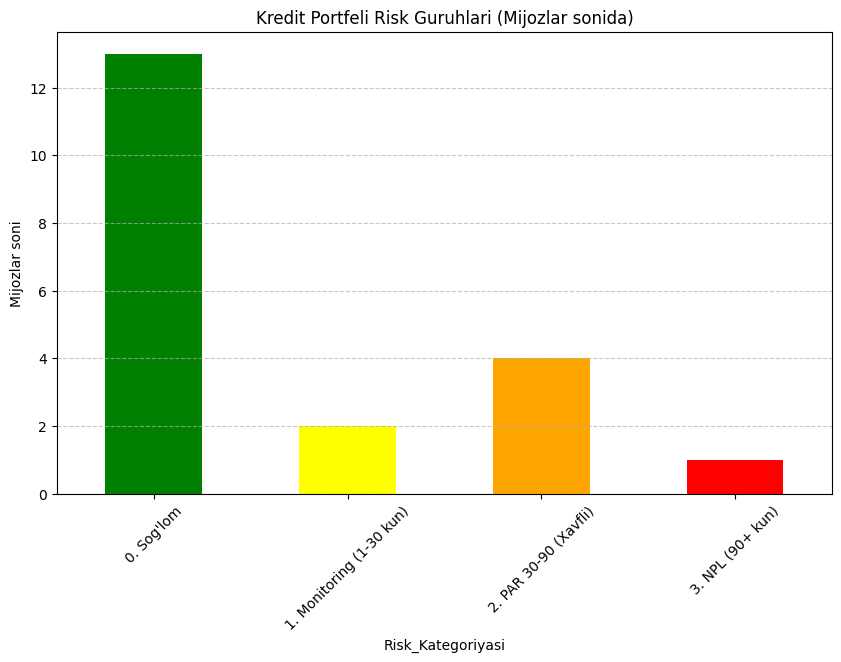

In [10]:
import matplotlib.pyplot as plt

# Risk guruhlarini grafikda ko'rsatish
plt.figure(figsize=(10,6))
df_risk.set_index('Risk_Kategoriyasi')['Mijozlar_Soni'].plot(kind='bar', color=['green', 'yellow', 'orange', 'red'])
plt.title('Kredit Portfeli Risk Guruhlari (Mijozlar sonida)')
plt.ylabel('Mijozlar soni')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()